# Python Data Cleaning & Visualization (Marketing Data)

This notebook was originally created in Google Colab.

**How to run locally:**
- Place the required `.csv` files in a folder named `data/` next to notebook
- Then run the cells from top to bottom

> Note: Google Drive mounting code was removed to keep the notebook portable.

In [ ]:
import os
DATA_DIR = 'data'  # folder with input CSV files

In [ ]:
import pandas as pd

## 1. Data Loading

In [ ]:
import pandas as pd
sales = pd.read_csv(os.path.join(DATA_DIR, 'sales_v2023-07-09.csv'))
sales.head()

,order_id,date,customer_id,category,region,sales,quantity,discount
0,59570135,2017-10-16,512.0,Одежда и обувь,Ставропольский край,1301.0,2.0,0.00
1,16578697,2017-07-18,512.0,Одежда и обувь,Ставропольский край,3530.0,4.0,0.05
2,46943601,2017-07-05,512.0,Бытовая техника,Ставропольский край,5773.0,1.0,0.10
3,42436035,2017-02-18,512.0,Спорт и отдых,Ставропольский край,4723.0,3.0,0.03
4,49798299,2017-09-08,512.0,Красота,Ставропольский край,1936.0,3.0,0.00


In [ ]:
returns = pd.read_csv(os.path.join(DATA_DIR, 'returns_v2023-07-09.csv'))
returns.head()

,order_id,return
0,59570135,0
1,16578697,0
2,46943601,0
3,42436035,0
4,49798299,0


## 2. Data Merging

In [ ]:
%%time

joined = sales.merge(returns, on='order_id')
joined.head()

CPU times: user 224 ms, sys: 63.8 ms, total: 288 ms
Wall time: 295 ms


,order_id,date,customer_id,category,region,sales,quantity,discount,return
0,59570135,2017-10-16,512.0,Одежда и обувь,Ставропольский край,1301.0,2.0,0.00,0
1,16578697,2017-07-18,512.0,Одежда и обувь,Ставропольский край,3530.0,4.0,0.05,0
2,46943601,2017-07-05,512.0,Бытовая техника,Ставропольский край,5773.0,1.0,0.10,0
3,42436035,2017-02-18,512.0,Спорт и отдых,Ставропольский край,4723.0,3.0,0.03,0
4,49798299,2017-09-08,512.0,Красота,Ставропольский край,1936.0,3.0,0.00,0


In [ ]:
sales.query('category in ["Бытовая техника", "Одежда и обувь"]')

,order_id,date,customer_id,category,region,sales,quantity,discount
0,59570135,2017-10-16,512.0,Одежда и обувь,Ставропольский край,1301.0,2.0,0.00
1,16578697,2017-07-18,512.0,Одежда и обувь,Ставропольский край,3530.0,4.0,0.05
2,46943601,2017-07-05,512.0,Бытовая техника,Ставропольский край,5773.0,1.0,0.10
12,3088702,2017-09-05,513.0,Одежда и обувь,Московская область,1932.0,1.0,0.05
28,94577895,2017-08-05,516.0,Одежда и обувь,Хабаровский край,1210.0,1.0,0.10
...,...,...,...,...,...,...,...,...
151680,50585989,2017-12-03,29774.0,Одежда и обувь,Красноярский край,1632.0,2.0,0.00
151682,90419705,2017-04-25,29775.0,Бытовая техника,Краснодарский край,1222.0,2.0,0.00
151684,14217628,2017-04-08,29776.0,Одежда и обувь,Владимирская область,923.0,2.0,0.05
151689,59999477,2017-10-02,29777.0,Бытовая техника,Красноярский край,13768.0,0.0,0.03


In [ ]:
import pandas as pd
sales = pd.read_csv(os.path.join(DATA_DIR, 'sales_v2023-07-09.csv'))
sales.groupby("region")["sales"].sum().idxmax()

'Амурская область'

In [ ]:
import pandas as pd

sales = pd.read_csv(os.path.join(DATA_DIR, 'sales_v2023-07-09.csv'))
returns = pd.read_csv(os.path.join(DATA_DIR, 'returns_v2023-07-09.csv'))

joined = sales.merge(returns, on='order_id')
pivot = joined.pivot_table(index='region', columns='return', values='sales', aggfunc='count')
pivot

return,0,1
region,,
Амурская область,150114,72117
Владимирская область,67494,23080
Иркутская область,93629,39018
Краснодарский край,107629,25989
Красноярский край,61908,28426
Ленинградская область,136665,39939
Московская область,175699,45141
Приморский край,91062,43482
Смоленская область,73957,14581


In [ ]:
import pandas as pd

sales = pd.read_csv(os.path.join(DATA_DIR, 'sales_v2023-07-09.csv'))
returns = pd.read_csv(os.path.join(DATA_DIR, 'returns_v2023-07-09.csv'))

joined = sales.merge(returns, on='order_id')
pivot = joined.pivot_table(index='region', columns='return', values='sales', aggfunc='count')
pivot['returns_share'] = pivot[1] / (pivot[0] + pivot[1])
pivot

return,0,1,returns_share
region,,,
Амурская область,150114,72117,0.324514
Владимирская область,67494,23080,0.254819
Иркутская область,93629,39018,0.294149
Краснодарский край,107629,25989,0.194502
Красноярский край,61908,28426,0.314677
Ленинградская область,136665,39939,0.226150
Московская область,175699,45141,0.204406
Приморский край,91062,43482,0.323181
Смоленская область,73957,14581,0.164686


## 3. Exploratory Data Analysis

In [ ]:
import pandas as pd
df = pd.read_csv(os.path.join(DATA_DIR, 'sales_with_duplicates.csv'))
data = pd.read_csv('data/numbers.csv', names = ['price'])
joined = df.join(data, how = 'inner')
joined.head()

,order_id,date,customer_id,category,region,sales,quantity,discount,price
0,14186940,2017-07-20,513,Спорт и отдых,Краснодарский край,10414.0,3,0.00,1010.005807
1,46863464,2017-01-27,514,Спорт и отдых,Владимирская область,4147.0,3,0.00,997.384196
2,98992195,2017-01-22,514,Продукты питания,Владимирская область,1136.0,4,0.00,997.088963
3,29193654,2018-02-18,514,Продукты питания,Владимирская область,938.0,1,0.03,1006.088979
4,63339281,2017-01-23,518,Одежда и обувь,Краснодарский край,1135.0,1,0.00,998.465880


In [ ]:
duplicates = df.duplicated()
duplicates

,0
0,False
1,False
2,False
3,False
4,False
...,...
1688219,False
1688220,False
1688221,False
1688222,False


In [ ]:
num_duplicates = df.duplicated().sum()
num_duplicates

np.int64(49203)

In [ ]:
joined[~pd.isnull(joined['price'])].head()

,order_id,date,customer_id,category,region,sales,quantity,discount,price
0,14186940,2017-07-20,513,Спорт и отдых,Краснодарский край,10414.0,3,0.00,1010.005807
1,46863464,2017-01-27,514,Спорт и отдых,Владимирская область,4147.0,3,0.00,997.384196
2,98992195,2017-01-22,514,Продукты питания,Владимирская область,1136.0,4,0.00,997.088963
3,29193654,2018-02-18,514,Продукты питания,Владимирская область,938.0,1,0.03,1006.088979
4,63339281,2017-01-23,518,Одежда и обувь,Краснодарский край,1135.0,1,0.00,998.465880


In [ ]:
import pandas as pd
from numpy import quantile


df = pd.read_csv(os.path.join(DATA_DIR, 'sales_with_duplicates.csv'))
data = pd.read_csv('data/numbers.csv', names = ['price'])
joined = df.join(data, how = 'inner')


clothing_prices = joined[joined['category'] == 'Одежда и обувь']['price']


quantile_05 = quantile(clothing_prices.dropna(), 0.05)
quantile_95 = quantile(clothing_prices.dropna(), 0.95)


joined_filtered = joined[
    (joined['category'] == 'Одежда и обувь') &
    (joined['price'] >= quantile_05) &
    (joined['price'] <= quantile_95)
]
joined_filtered.head()

,order_id,date,customer_id,category,region,sales,quantity,discount,price
4,63339281,2017-01-23,518,Одежда и обувь,Краснодарский край,1135.0,1,0.00,998.465880
6,98709601,2017-01-15,519,Одежда и обувь,Владимирская область,1737.0,1,0.05,985.903705
8,50948190,2017-01-11,522,Одежда и обувь,Приморский край,2309.0,2,0.10,999.412856
9,20172776,2017-01-23,522,Одежда и обувь,Приморский край,4406.0,1,0.03,1002.781523
15,10603757,2017-02-23,530,Одежда и обувь,Иркутская область,1727.0,3,0.00,1005.550048


## 4. Data Visualization

<Axes: >

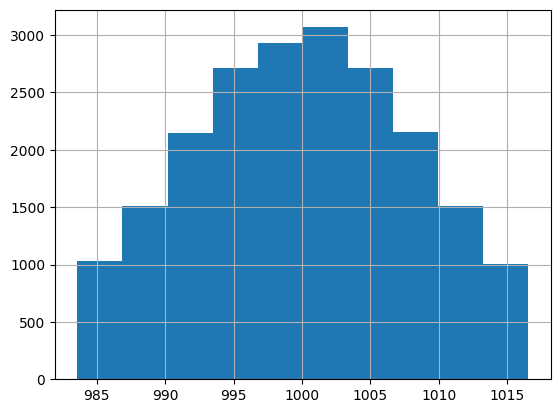

In [ ]:
joined_filtered['price'].hist()

In [ ]:
import pandas as pd
sales = pd.read_csv(os.path.join(DATA_DIR, 'sales_v2023-07-09.csv'))

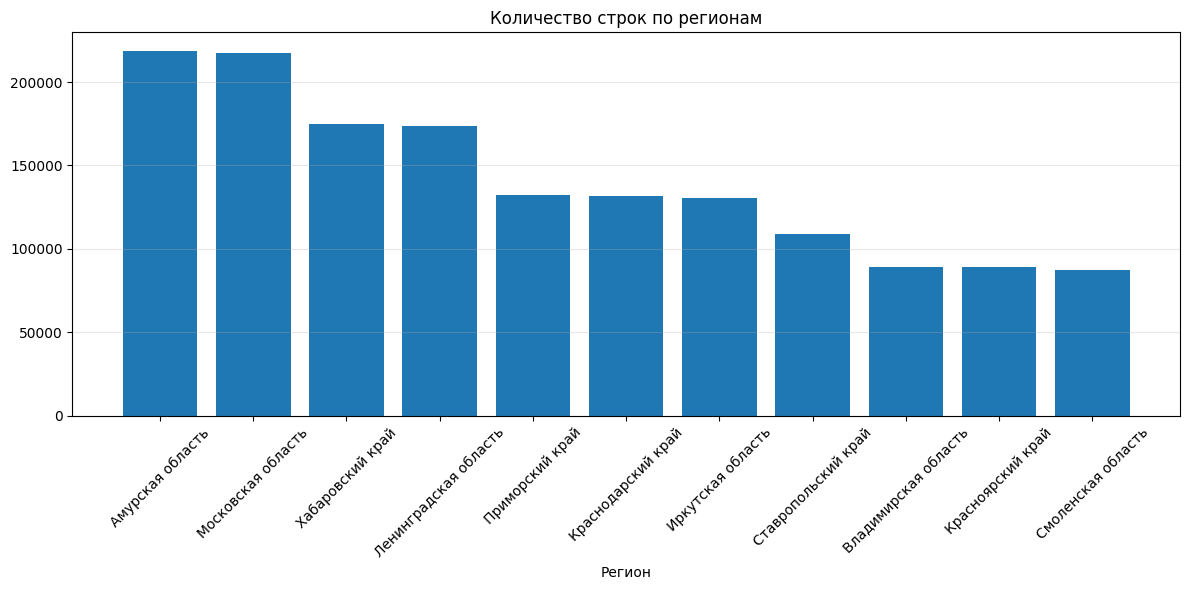

In [ ]:
import matplotlib.pyplot as plt

region_counts = sales['region'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(region_counts.index, region_counts.values)

plt.title('Количество строк по регионам')
plt.xlabel('Регион')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

In [ ]:
sales_region_long = sales_region.stack().reset_index(name='sales')
sales_region_long['month'] = sales_region_long['month'].astype(str)

fig = px.line(sales_region_long, x='month', y='sales', color='region')

fig.update_layout(
    updatemenus=[
        {
            "buttons": [{ "label": 'Все регионы', "method": "restyle", "args": [{"visible": [True for _ in fig.data]}], }] +
            [
                {
                    "label": t.name,
                    "method": "restyle",
                    "args": [{"visible": [t2.name == t.name for t2 in fig.data]}],
                }
                for t in fig.data
            ]
        }
    ]
)

fig.show()